# Tutorial: MLP para regresion con Keras

En este cuaderno entrenaremos dos modelos MLP (perceptron multicapa) para un problema de regresion:

1. Modelo base sin regularizacion.
2. Modelo con regularizacion (L2).

Compararemos:
- Curvas de entrenamiento y test (loss y MAE).
- Prediccion frente a valor real.
- Metricas tipicas de evaluacion en regresion.


In [1]:
import random
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error,
)

import keras
from keras import layers, regularizers

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
keras.utils.set_random_seed(SEED)

print("Keras version:", keras.__version__)
print("Backend activo:", keras.backend.backend())


Keras version: 3.10.0
Backend activo: tensorflow


In [2]:
# Cargar dataset de regresion
dataset = load_diabetes()
X = dataset.data.astype("float32")
y = dataset.target.astype("float32")
feature_names = dataset.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape, "y_test :", y_test.shape)
print("Rango del target:", float(y.min()), "->", float(y.max()))


X_train: (353, 10) y_train: (353,)
X_test : (89, 10) y_test : (89,)
Rango del target: 25.0 -> 346.0


In [3]:
import pandas as pd

# ver “cabecera” de la matriz de entradas
try:

    df_X = pd.DataFrame(X[:5], columns=feature_names)
    display(df_X)
except ImportError:
    print("Primeras filas de X:")
    print(X[:5])

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


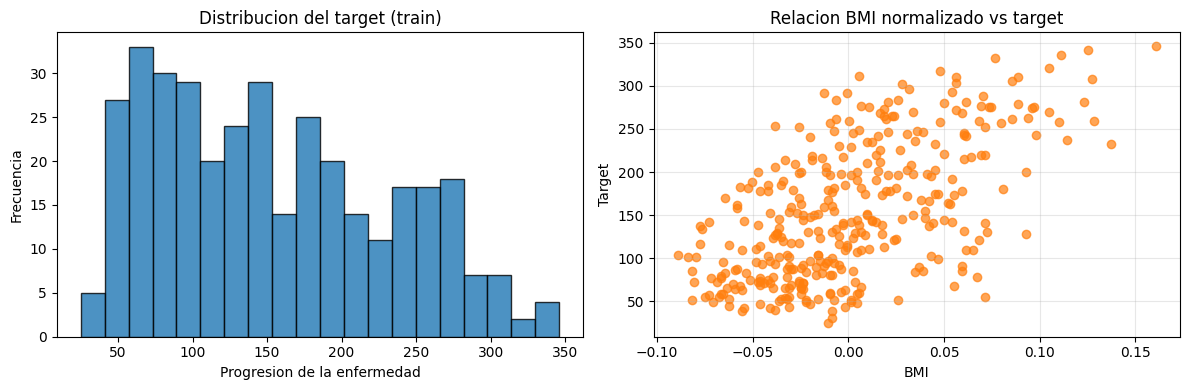

In [4]:
# Visualizar el dataset
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y_train, bins=20, color="#1f77b4", alpha=0.8, edgecolor="black")
axes[0].set_title("Distribucion del target (train)")
axes[0].set_xlabel("Progresion de la enfermedad")
axes[0].set_ylabel("Frecuencia")

bmi_idx = feature_names.index("bmi")
axes[1].scatter(X_train[:, bmi_idx], y_train, alpha=0.7, color="#ff7f0e")
axes[1].set_title("Relacion BMI normalizado vs target")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Target")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [5]:
# Preprocesado para MLP: estandarizar las variables de entrada
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

input_dim = X_train_scaled.shape[1]

print("Input dimension para MLP:", input_dim)
print("Media aproximada tras escalado:", np.round(X_train_scaled.mean(axis=0), 3))


Input dimension para MLP: 10
Media aproximada tras escalado: [-0. -0.  0. -0.  0.  0.  0. -0.  0. -0.]


## Utilidades para entrenamiento y evaluacion


In [6]:
def plot_history(history, title):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(epochs, hist["loss"], label="train loss")
    axes[0].plot(epochs, hist["val_loss"], label="test loss")
    axes[0].set_title(f"{title} - Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("MSE")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(epochs, hist["mae"], label="train mae")
    axes[1].plot(epochs, hist["val_mae"], label="test mae")
    axes[1].set_title(f"{title} - MAE")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("MAE")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def evaluate_model(model, X_test, y_test, title):
    y_pred = model.predict(X_test, verbose=0).squeeze()

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred)

    print(f"=== {title} ===")
    print(f"MAE : {mae:.4f}")
    print(f"MSE : {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2  : {r2:.4f}")
    print(f"MAPE: {mape:.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].scatter(y_test, y_pred, alpha=0.75, color="#2ca02c")
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    axes[0].plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2)
    axes[0].set_title(f"Prediccion vs valor real - {title}")
    axes[0].set_xlabel("Valor real")
    axes[0].set_ylabel("Prediccion")
    axes[0].grid(True, alpha=0.3)

    residuals = y_test - y_pred
    axes[1].hist(residuals, bins=20, color="#d62728", alpha=0.8, edgecolor="black")
    axes[1].set_title(f"Distribucion de residuos - {title}")
    axes[1].set_xlabel("Residuo")
    axes[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

    return {
        "Modelo": title,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2,
        "MAPE": mape,
    }


## 1) Modelo base sin regularizacion


In [7]:
model_base = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(1),
])

model_base.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)

model_base.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
EPOCHS = 250
BATCH_SIZE = 256

history_base = model_base.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 988ms/step - loss: 29950.1016 - mae: 154.4605 - val_loss: 26455.0508 - val_mae: 145.4271
Epoch 2/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 29884.7539 - mae: 154.2621 - val_loss: 26396.3652 - val_mae: 145.2370
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - loss: 29820.0605 - mae: 154.0653 - val_loss: 26338.0176 - val_mae: 145.0468
Epoch 4/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 29754.9316 - mae: 153.8663 - val_loss: 26279.1738 - val_mae: 144.8541
Epoch 5/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 29688.7363 - mae: 153.6640 - val_loss: 26218.0723 - val_mae: 144.6534
Epoch 6/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 29620.3301 - mae: 153.4550 - val_loss: 26154.0684 - val_mae: 144.4429
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 29549.2305 - mae: 153.2372 - val_loss: 26086.0723 - val_mae: 144.2197
Epoch 8/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 29474.0879 - mae: 153.0068 - val_loss: 26013.

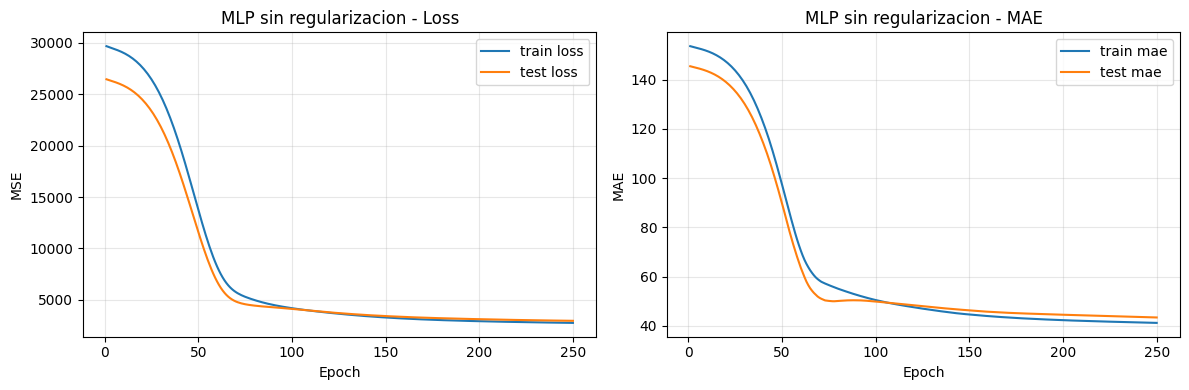

=== MLP sin regularizacion ===
MAE : 43.3899
MSE : 2958.5063
RMSE: 54.3922
R2  : 0.4416
MAPE: 0.3650


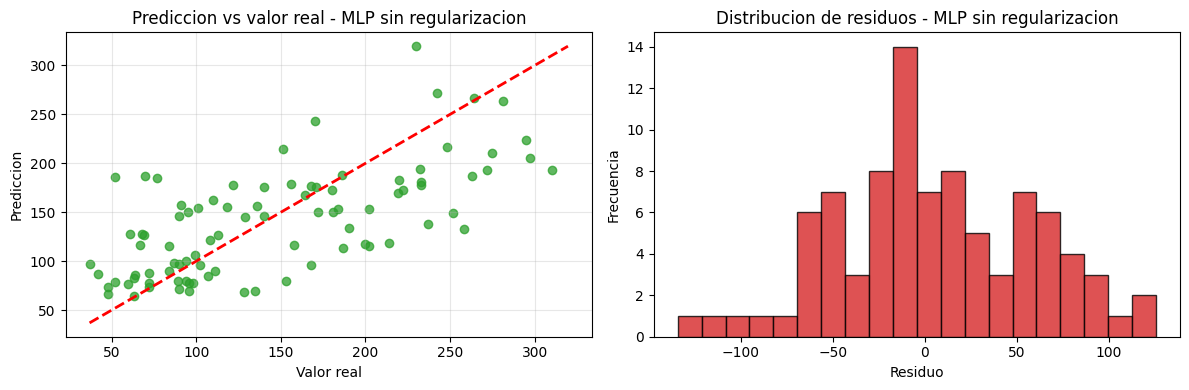

In [9]:
plot_history(history_base, "MLP sin regularizacion")
metrics_base = evaluate_model(
    model_base, X_test_scaled, y_test, "MLP sin regularizacion"
)


## 2) Modelo con regularizacion




In [10]:
l2_lambda = 1e-3


model_reg = keras.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, kernel_regularizer=regularizers.l2(l2_lambda)),
    layers.Activation("relu"),
    layers.Dense(64, kernel_regularizer=regularizers.l2(l2_lambda)),
    layers.Activation("relu"),
    layers.Dense(1),
])

model_reg.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse",
    metrics=["mae"],
)



model_reg.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
EPOCHS = 250
BATCH_SIZE = 256

history_reg = model_reg.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1,
)


Epoch 1/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - loss: 29816.3711 - mae: 154.0453 - val_loss: 26308.6934 - val_mae: 144.9116
Epoch 2/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 29724.7734 - mae: 153.7609 - val_loss: 26217.9980 - val_mae: 144.6074
Epoch 3/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - loss: 29628.7832 - mae: 153.4624 - val_loss: 26122.8418 - val_mae: 144.2882
Epoch 4/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 29528.0293 - mae: 153.1482 - val_loss: 26022.5332 - val_mae: 143.9521
Epoch 5/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - loss: 29421.3672 - mae: 152.8147 - val_loss: 25916.3633 - val_mae: 143.5966
Epoch 6/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 29307.5918 - mae: 152.4587 - val_loss: 25803.7266 - val_mae: 143.2197
Epoch 7/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 29186.0508 - mae: 152.0780 - val_loss: 25683.2520 - val_mae: 142.8158
Epoch 8/250
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 29055.7422 - mae: 151.6699 - val_loss: 25554.568

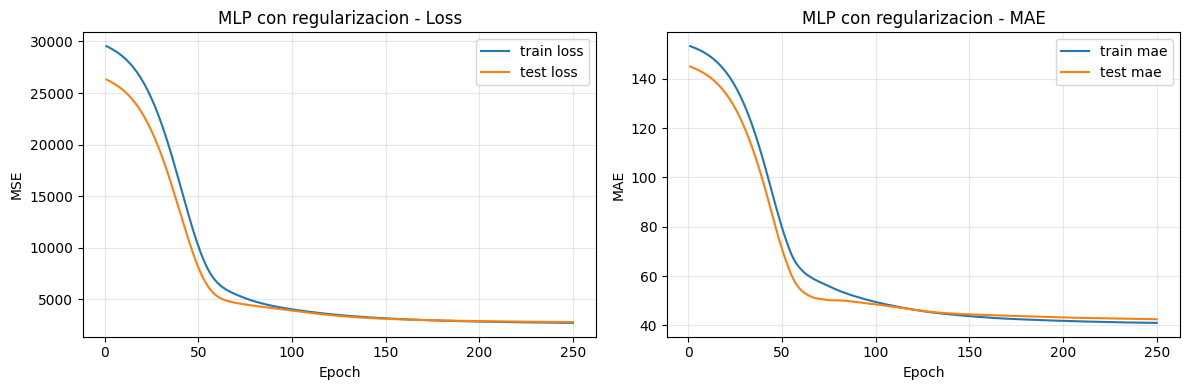

=== MLP con regularizacion ===
MAE : 42.5171
MSE : 2800.6965
RMSE: 52.9216
R2  : 0.4714
MAPE: 0.3609


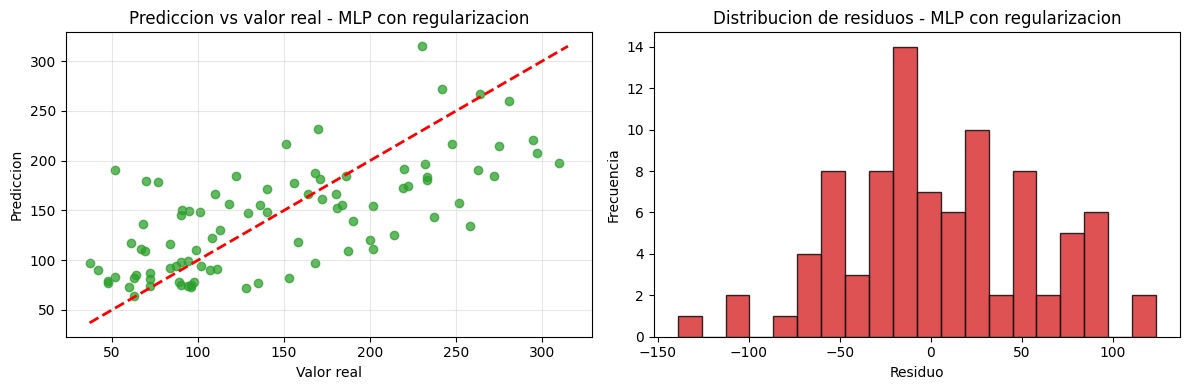

In [12]:
plot_history(history_reg, "MLP con regularizacion")
metrics_reg = evaluate_model(
    model_reg, X_test_scaled, y_test, "MLP con regularizacion"
)


## Comparacion final


In [13]:
rows = [metrics_base, metrics_reg]

try:
    import pandas as pd

    display(pd.DataFrame(rows).round(4))
except Exception:
    for row in rows:
        print(row)


,Modelo,MAE,MSE,RMSE,R2,MAPE
0,MLP sin regularizacion,43.3899,2958.5063,54.3922,0.4416,0.3650
1,MLP con regularizacion,42.5171,2800.6965,52.9216,0.4714,0.3609
